In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory
from matplotlib.ticker import FuncFormatter

Импортируем коэффициенты и ковариационную матрицу из STATA

In [2]:
# коэффициенты
b_df = pd.read_excel("data/m3_b.xlsx", index_col=0)
b = b_df.iloc[0] 

# ковариационная матрица
V = pd.read_excel("data/m3_V.xlsx", index_col=0)
V = V.loc[b.index, b.index]

Полезные функции

In [3]:
shock_date = pd.Timestamp("2022-02-01")

# Создаем папку для сохранения рисунков
save_dir = "figures"
os.makedirs(save_dir, exist_ok=True)

In [4]:
def human_format(x, pos):
    """
    Красивый формат чисел на оси Y:
    1 200 000 000 -> 1.2B
    35 000 000    -> 35M
    8 000         -> 8K
    """
    abs_x = abs(x)
    if abs_x >= 1e9:
        return f"{x/1e9:.1f}B"
    elif abs_x >= 1e6:
        return f"{x/1e6:.1f}M"
    elif abs_x >= 1e3:
        return f"{x/1e3:.0f}K"
    return f"{x:.0f}"


def percent_format(x, pos):
    """Формат процентов для оси Y."""
    return f"{x:.0f}%"


def apply_thesis_style(ax, title, ylabel=None, xlabel=None, highlight_post_period=True):
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12, labelpad=15)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12, labelpad=15)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)
    ax.tick_params(axis="both", labelsize=11)

    if highlight_post_period:
        # правая граница именно текущей оси
        x_left = mdates.date2num(shock_date)
        x_right = ax.get_xlim()[1]

        # красим до конца графика
        ax.axvspan(x_left, x_right, alpha=0.08, color="#B22222")
        ax.axvline(shock_date, color="#8B0000", linestyle="--", linewidth=1.4, alpha=0.8)

        # X в координатах данных, Y в долях оси
        trans = blended_transform_factory(ax.transData, ax.transAxes)

        # подпись чуть левее правого края красной зоны
        x_text = x_right - 0.02 * (x_right - x_left)

        ax.text(
            x_text, 0.04,
            "Постсанкционный период",
            transform=trans,
            color="#8B0000",
            fontsize=10,
            ha="right",
            va="bottom",
            linespacing=1.0
        )

def save_figure(fig, filename):
    """
    Сохраняем график сразу в PNG и PDF.
    PNG удобно вставлять в текст, PDF хорош для печати.
    """
    png_path = os.path.join(save_dir, f"{filename}.png")
    fig.savefig(png_path, dpi=400, bbox_inches="tight")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

### Построение графика для гетерогенности санкционного эффекта по группам товаров


In [5]:
hs_map = {
    1: "9018",
    2: "9019",
    3: "9020",
    4: "9021",
    5: "9022",
    6: "9025",
    7: "9027",
    8: "9030",
    9: "9031",
}

Доверительные интервалы для линейной комбинации коэффициентов

In [6]:
base_name = "sanctions_proxy_smooth_l1"

def effect_for_hs(h, b, V):
    L = pd.Series(0.0, index=b.index)

    # базовый наклон санкционного индекса
    L[base_name] = 1.0

    # если это не базовая группа, добавляем interaction
    if h != 1:
        inter_name = f"{h}.hs_id#c.sanctions_proxy_smooth_l1"
        L[inter_name] = 1.0

    est = float(L @ b)
    var = float(L @ V @ L)
    se = np.sqrt(var)
    ci_low = est - 1.96 * se
    ci_high = est + 1.96 * se

    return est, se, ci_low, ci_high

In [7]:
rows = []
for h, hs in hs_map.items():
    est, se, ci_low, ci_high = effect_for_hs(h, b, V)
    rows.append({
        "hs_id": h,
        "hs": hs,
        "coef": est,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

res = pd.DataFrame(rows)
res

,hs_id,hs,coef,se,ci_low,ci_high
0,1,9018,-0.079958,0.022889,-0.124820,-0.035096
1,2,9019,-0.127818,0.035032,-0.196480,-0.059156
2,3,9020,-0.782470,0.089097,-0.957100,-0.607841
3,4,9021,-0.051975,0.025197,-0.101360,-0.002589
4,5,9022,-0.128380,0.040687,-0.208126,-0.048634
5,6,9025,-0.371779,0.060194,-0.489759,-0.253799
6,7,9027,-0.329184,0.047276,-0.421844,-0.236523
7,8,9030,-0.520445,0.058654,-0.635408,-0.405483
8,9,9031,-0.446935,0.044670,-0.534488,-0.359382


Переводим в проценты эфффект

In [8]:
res["pct_effect"] = 100 * (np.exp(res["coef"]) - 1)
res["pct_ci_low"] = 100 * (np.exp(res["ci_low"]) - 1)
res["pct_ci_high"] = 100 * (np.exp(res["ci_high"]) - 1)

Рисуем график

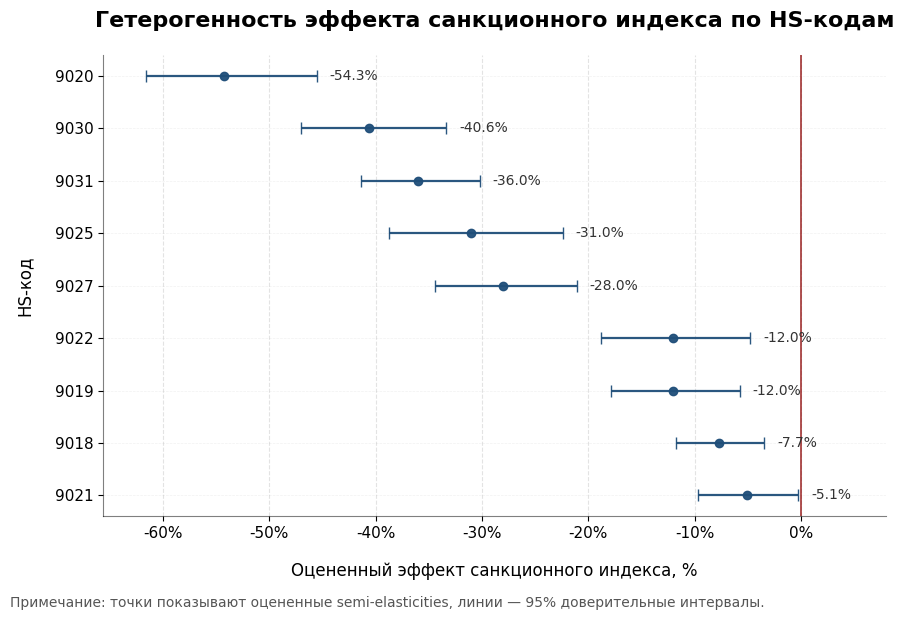

In [10]:
# сортируем от самого сильного отрицательного эффекта к более слабому
plot_df = res.sort_values("pct_effect").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))

y = np.arange(len(plot_df))
x = plot_df["pct_effect"].values

xerr = np.vstack([
    x - plot_df["pct_ci_low"].values,
    plot_df["pct_ci_high"].values - x
])

# цвет: значимо отрицательные, значимо положительные, незначимые
colors = []
for _, row in plot_df.iterrows():
    if row["pct_ci_high"] < 0:
        colors.append("#1F4E79")   # отрицательный значимый эффект
    elif row["pct_ci_low"] > 0:
        colors.append("#5A9C72")   # положительный значимый эффект
    else:
        colors.append("#8A8A8A")   # доверительный интервал пересекает 0

# доверительные интервалы и точки
for i in range(len(plot_df)):
    ax.errorbar(
        x[i], y[i],
        xerr=np.array([[xerr[0, i]], [xerr[1, i]]]),
        fmt="o",
        markersize=6,
        capsize=4,
        linewidth=1.6,
        color=colors[i],
        ecolor=colors[i],
        alpha=0.95
    )

# вертикальная линия нулевого эффекта
ax.axvline(0, color="#8B0000", linewidth=1.2, alpha=0.8)

# подписи значений
for i, row in plot_df.iterrows():
    ax.text(
        row["pct_ci_high"] + 1.2,
        i,
        f"{row['pct_effect']:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        color="#333333"
    )

# оси
ax.set_yticks(y)
ax.set_yticklabels(plot_df["hs"])
ax.invert_yaxis()

ax.xaxis.set_major_formatter(FuncFormatter(percent_format))

apply_thesis_style(
    ax,
    title="Гетерогенность эффекта санкционного индекса по HS-кодам",
    xlabel="Оцененный эффект санкционного индекса, %",
    ylabel="HS-код",
    highlight_post_period=False
)

# для горизонтального графика лучше сетка по X
ax.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.35)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.18)

# немного пространства справа для подписей
x_min = plot_df["pct_ci_low"].min()
x_max = max(plot_df["pct_ci_high"].max(), 0)
ax.set_xlim(x_min - 4, x_max + 8)

# подпись под графиком
fig.text(
    0.01, -0.02,
    "Примечание: точки показывают оцененные semi-elasticities, линии — 95% доверительные интервалы.",
    ha="left",
    fontsize=10,
    color="#555555"
)

plt.tight_layout()

# если хочешь сохранить
save_figure(fig, "hs_sanctions_effect_heterogeneity")

График показывает, что эффект санкционного индекса неодинаков для разных товарных групп. Во всех HS-кодах точечные оценки отрицательные, что указывает на связь роста санкционного давления со снижением импорта медицинского оборудования. Наиболее сильное снижение наблюдается для HS 9020, а также для групп 9030, 9031 и 9025. Наименее выраженный эффект зафиксирован для HS 9021: его доверительный интервал расположен ближе всего к нулю. Совместный тест на различие эффектов между HS-кодами подтверждает наличие статистически значимой гетерогенности: $\chi^2(8)=360.25$, $p<0.001$.